# This template will calculate the quantum yield of singlet oxygen from a reference sensitizer of Perinapthenone and from 2NB chemical actinometry

# Things to note before using this template
- You will need to upload UV-Vis absorbance data and manually input HPLC integration data (in the 6th executable cell with code) 
- Make sure you upload the csv data files from UV-Vis, they should work in the format that the UV-Vis software provides them, otherwise convert it to UTF-8 encoded csv files (but only if you need to, its easier to just upload the files directly from UV-Vis)
- Everywhere there is _____ , change a name to match the name of your file
- When you are pulling out the absorbance data, change the "unnamed" variables to match the measurements you took 
- This template code assumes you ran triplicates for your sample, if your experiment differs from this set up you will need to modify the variables/calculations accordingly

- Any questions/comments/suggestions can be sent to Keighan Gemmell (keighan@chem.ubc.ca) 
- Last updated on May 6th, 2025

# Import Packages

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import math

# Read in the Irradiance Data

In [ ]:
# Read the irradiance data from the CSV file
dfIrr2 = pd.read_csv('______.csv', skiprows=[1])
dfIrr2.columns = ['AbsoluteIrradiance:245', 'Unnamed: 1']

# Round the wavelengths to the nearest whole number
dfIrr2['rounded_wavelength'] = dfIrr2['AbsoluteIrradiance:245'].round()

dfIrr2.loc[dfIrr2['rounded_wavelength'] < 280, 'Unnamed: 1'] = 0

# Filter the DataFrame to include only wavelengths from 200 to 800
filtered_df1 = dfIrr2[(dfIrr2['rounded_wavelength'] >= 200) & (dfIrr2['rounded_wavelength'] <= 800)]

# Group by the rounded wavelengths and calculate the average irradiance
average_irradiance2 = filtered_df1.groupby('rounded_wavelength')['Unnamed: 1'].mean().reset_index()

# Rename the columns for clarity
average_irradiance2.columns = ['wavelength', 'average_irradiance']

Irr2=average_irradiance2['average_irradiance']
wavelengthIrr=average_irradiance2['wavelength']

Irr2=Irr2.astype(float)
wavelengthIrr=wavelengthIrr.astype(float)
I_rel2=Irr2/np.sum(Irr2)

# 2NB Actinometry

In [ ]:
#First you will need to upload your csv file to this server
df = pd.read_csv('../intercomparison.csv')
wavelength_2NB=df['λ (nm)']
E2NB=df['2NB E']
E2NB=E2NB[:501]
wavelength_2NB=wavelength_2NB[:501]

I_rel_sub=I_rel2[:501]
I_rel_sub=I_rel_sub[::-1]

plt.plot(wavelength_2NB,E2NB/np.sum(E2NB))
plt.plot(wavelength_2NB,I_rel_sub)

In [ ]:
times=np.array([0,20,40,60,80,120,180]) 
deg=[]
deglog=np.log([i/deg[0] for i in deg])
kobs_2NB=-(np.polyfit(times,deglog,1)[0])
#Plot the results
plt.plot(times,deglog,'bo')
plt.plot(times,times*(-kobs_2NB),'b--')

#Plot legend and axis labels
#plt.legend(fontsize=14)
plt.ylabel('ln(${[2NB]_t}$/${[2NB]_0}$)',fontsize=12)
plt.xlabel('Irradiation time (sec)',fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
#plt.savefig('2NB_decay')
plt.show()

In [ ]:
quantum2NB=0.41
def optimize_scaling_factor(quantum2NB, E2NB, I_rel_sub, known_value):
    """
    Optimize the scaling factor to match the known action_spectra value.

    Parameters:
        quantum2NB: Quantum yield.
        E2NB (pandas.Series or np.ndarray): Molar absorptivity data.
        I_rel_sub (pandas.Series or np.ndarray): Relative intensity data.
        known_value (float): The known action_spectra value to match.

    Returns:
        float: The optimal scaling factor.
    """
    # Reset index and ensure inputs are numpy arrays for better performance
    quantum2NB = quantum2NB
    E2NB = E2NB
    I_rel_sub = I_rel_sub.reset_index(drop=True).values

    # Objective function to minimize the error
    def objective(scaling_factor):
        action_spectra = 2.303 * scaling_factor * quantum2NB * E2NB * I_rel_sub
        error = np.abs(np.sum(action_spectra) - known_value)  # Minimize absolute error
        return error

    # Initial guess for the scaling factor
    initial_guess = 1.0

    # Perform the optimization
    result = minimize(objective, initial_guess, method='Nelder-Mead',tol=1e-10)

    if result.success:
        optimal_scaling_factor = result.x[0]
        
        # Calculate the optimized action_spectra with the optimal scaling factor
        optimized_action_spectra = 2.303 * optimal_scaling_factor * quantum2NB * E2NB * I_rel_sub
        optimized_value = np.sum(optimized_action_spectra)

        # Print the known and optimized values for confirmation
        print(f"Known value: {known_value}")
        print(f"Optimized action_spectra value: {optimized_value}")

        return optimal_scaling_factor
    else:
        raise ValueError("Optimization failed: " + result.message)

scaling_factor = optimize_scaling_factor(quantum2NB, E2NB, I_rel_sub, kobs_2NB)
print(f"Optimized scaling factor: {scaling_factor}")
print(kobs_2NB)

In [ ]:
I_abs_2NB=I_rel2.reset_index(drop=True)*scaling_factor

In [ ]:
c=3*10**8 #m/s
h=6.626*10**-34 #J s
Na=6.023*10**23 #mol^-1

print('I_abs_2NB=',np.sum(I_abs_2NB.reset_index(drop=True)*h*c*Na*10**10/wavelengthIrr.reset_index(drop=True)),'W m^2')

# Load in UV-Vis absorbance data

In [ ]:
#First you will need to upload your csv file to this server
#then read in csv file as pandas dataframe, skipping the 2nd row
df = pd.read_csv('_____.csv', skiprows=[1]) #change the name of the csv file to the name of the file you imported

#this will output the table again from pandas (pd). make sure you are pulling out the correct data in the next block of code
df


In [ ]:
wavelength=np.linspace(800,200,601) #make wavelength array

#Note: It's weird, but when reading in the csv file to python, it sometimes auto-names the samples to "unnamed: #" 
#extract absorbances (remember that because of the layout of the csv file the absorbances will sometimes be 
#named "Unnamed: x (odd number). Just check that you are indexing the correct names when assigning variables
sample_abs = df['Unnamed: x'] 
blank_abs = df['Unnamed: x']
PN_abs = df['Unnamed: x']

#change all absorbances to type 'float' for ease of calculation
sample_abs=sample_abs.astype(float)
blank_abs=blank_abs.astype(float)
PN_abs=PN_abs.astype(float)


# Absorbance correction

In [ ]:
sample_abs=sample_abs-blank_abs
PN_abs=PN_abs-blank_abs

#Average absorbance from 700-800nm and subtract that from entire absorbance spectrum
sample_abs=sample_abs-np.mean(sample_abs[0:100])
PN_abs=PN_abs-np.mean(PN_abs[0:100])

#change all absorbances to type 'float' for ease of calculations 
sample_abs=sample_abs.astype(float)
PN_abs=PN_abs.astype(float)

#Set all negative values to 0
sample_abs[sample_abs < 0] = 0
PN_abs[PN_abs < 0] = 0

wavelength=wavelength[::-1]
PN_abs=PN_abs[::-1]
sample_abs=sample_abs[::-1]


# Plot UV-Vis Data Here

In [ ]:
plt.plot(wavelength,PN_abs)
plt.plot(wavelength,sample_abs)

# Put in your HPLC data here, will need to change times based on your sampling times 

In [ ]:
#Change times to match your times of sampling
times=np.array([0, 2, 4, 8, 16, 32, 60, 90, 120, 180, 240])*60 #put in times and convert to seconds
PNtime=np.array([0, 1, 2, 4, 8])*60 #put in times and convert to seconds
othertime=np.array([0, 240])*60 #put in times and convert to seconds

#Put in HPLC Results Here
sample=[, , , , , , , , , , ]

blank=[, , , , , , , , , , ]

PN=[, , , ,]

dark=[, ]

O2purge=[, ]


# Calculate ln(FFAt/FFA0) here

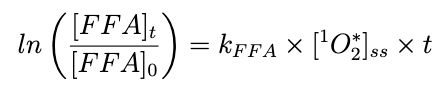

In [ ]:
#Don't worry, np.log is the natural logorithm, not base 10 (np.log10 is base 10)
samplelog=np.log([i/sample[0] for i in sample])
PNlog=np.log([i/PN[0] for i in PN])


# Obtain the slope using a 1st degree polynomial fit function 

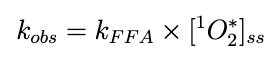

In [ ]:
#Obtain slope for all lines for quantum yield calculation, then take the negative to get kobs
#the [0] indicates I am pulling out the slope, i.e "m" in y=mx+b
kobs=-(np.polyfit(times,samplelog,1)[0])
kobsPN=-(np.polyfit(PNtime,PNlog,1)[0])

# Plot the HPLC results

In [ ]:
#Plot the results
plt.plot(times,samplelog,'bo',label='Sample')
plt.plot(times,times*(-kobs),'b--')

plt.plot(PNtime,PNlog,'o',label='PN')
plt.plot(PNtime,-kobsPN*PNtime)


#Plot legend and axis labels
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=3, fancybox=True, shadow=True)
plt.ylabel('ln(${[FFA]_t}$/${[FFA]_0}$)')
plt.xlabel('Irradiation time (sec)')
plt.show()


# Calculate screening factor and Rate of light absorbance

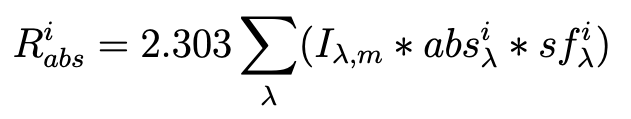

In [ ]:
#First subset absorbance to only include where there is irradiation 
alpha_PN=PN_abs[100:401]
alpha_sample=sample_abs[100:401]

I_2NB_sf=I_abs_2NB[100:401]

################################################################################
sf_PN=(np.sum((1-10**-alpha_PN.reset_index(drop=True))*I_2NB_sf.reset_index(drop=True)))/(np.sum((2.303*alpha_PN.reset_index(drop=True))*I_2NB_sf.reset_index(drop=True)))
print('PN Screening Factor = ',sf_PN)

sf_sample=(np.sum((1-10**-alpha_sample.reset_index(drop=True))*I_2NB_sf.reset_index(drop=True)))/(np.sum((2.303*alpha_sample.reset_index(drop=True))*I_2NB_sf.reset_index(drop=True)))
print('sample Screening Factor = ',sf_sample)

################################################################################
R_abs_PN=2.303*np.sum(PN_abs.reset_index(drop=True)*I_abs_2NB.reset_index(drop=True))
print('R_abs PN =',R_abs_PN)

R_abs_sample=2.303*np.sum(sample_abs.reset_index(drop=True)*I_abs_2NB.reset_index(drop=True))
print('R_abs sample =',R_abs_sample)

# Direct Quantum Yield Calculation

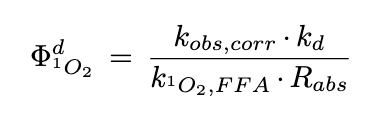

In [ ]:
Temp=22 # Put in average experimental temperature here
krxn=10**8 + (2.1E6*(Temp-22)) #from Appaini (2017)
kd=934.1813872772475*Temp + 258405.55551958136

kcorr_PN=kobsPN/sf_PN 
quantum_PN=(kcorr_PN*kd)/(R_abs_PN*krxn)
print('PN Quantum yield=',quantum_PN*100)

kcorr_sample=kobssample/sf_sample
quantum_sample=(kcorr_sample*kd)/(R_abs_sample*krxn)
print('Sample Quantum yield=',quantum_sample*100)

# Relative Quantum Yield Calculation

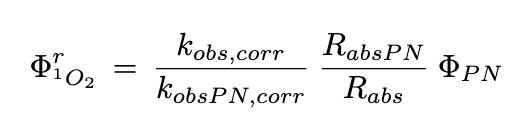

In [ ]:
Phi_PN=1 #from Schweitzer and Schmidt 

Phi_1O2_samp = (kobs1 / kobsPN) * (R_abs_PN / R_abs_samp) * Phi_PN
print('Quantum Yield Sample 1, relative:', Phi_1O2_samp)

#Multiply these values by 100 for a % quantum yield 

# Singlet Oxygen Steady State Concentration 

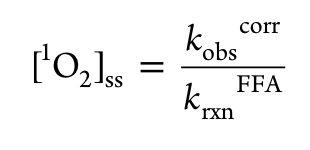

In [ ]:
Temp=22 #Put in your experimental temperature here, degrees C
kffa=10**8 + (2.1E6*(Temp-22)) #from Appaini (2017)

SS=kcorr_sample/kffa
print('Singlet Oxygen steady state concentration, sample:', SS) 

SS_PN=kcorr_PN/kffa
print('Singlet Oxygen steady state concentration, PN:', SS_PN) 


# Other potentially useful things

## Photochemical action region

In [ ]:
plt.plot(sample_abs.reset_index(drop=True)*I_abs_2NB.reset_index(drop=True))
plt.xlabel('Wavelength (nm)')